In [116]:
#Importing libraries and CSV File

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'/users/shahmeershaikh/downloads/marketing_AB.csv')

In [63]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [117]:
#Check if we have duplicates with respect to columns

df.duplicated(subset = 'user id').sum()

np.int64(0)

In [118]:
# Droping unwanted columns
df.drop(['Unnamed: 0', 'user id'], axis = 1, inplace = True)

In [105]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [119]:
# Check if the categorical variable have appropriate number of tests\
df_cat = df[['test group','converted','most ads day','most ads hour']]
df_cat.nunique()

test group        2
converted         2
most ads day      7
most ads hour    24
dtype: int64

In [120]:
# Check if the categorical variable have appropriate levels
for i in df_cat.columns:
    print(i.upper(),':',df_cat[i].unique())

TEST GROUP : ['ad' 'psa']
CONVERTED : [False  True]
MOST ADS DAY : ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']
MOST ADS HOUR : [20 22 18 10 14 13 19 11 12 16 21  3 23  4  8  0  2 15  1  6 17  7  9  5]


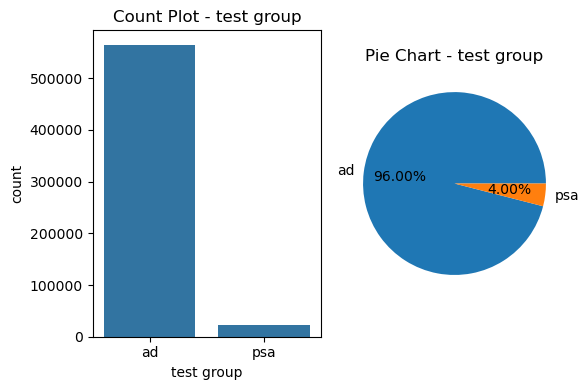

In [75]:
variable = 'test group'

plt.figure(figsize = (6,4))

#Count plot
plt.subplot(1,2,1)
sns.countplot(x= variable, data= df_cat)
plt.title (f'Count Plot - {variable}')

import matplotlib.pyplot as plt
from importlib import reload
reload(plt)

# Pie Chart
plt.subplot(1,2,2)
counts= df_cat[variable].value_counts()
plt.pie(counts, labels= counts.index, autopct= '%0.2f%%')
plt.title(f'Pie Chart - {variable}')

#Adjust
plt.tight_layout()

# Show the chart
plt.show()


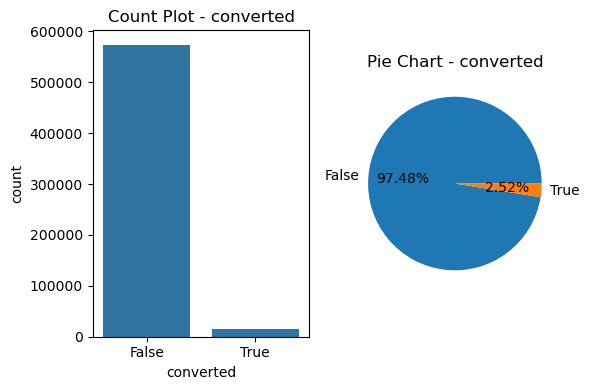

In [76]:
variable = 'converted'

plt.figure(figsize = (6,4))

#Count plot
plt.subplot(1,2,1)
sns.countplot(x= variable, data= df_cat)
plt.title (f'Count Plot - {variable}')

import matplotlib.pyplot as plt
from importlib import reload
reload(plt)

# Pie Chart
plt.subplot(1,2,2)
counts= df_cat[variable].value_counts()
plt.pie(counts, labels= counts.index, autopct= '%0.2f%%')
plt.title(f'Pie Chart - {variable}')

#Adjust
plt.tight_layout()

# Show the chart
plt.show()

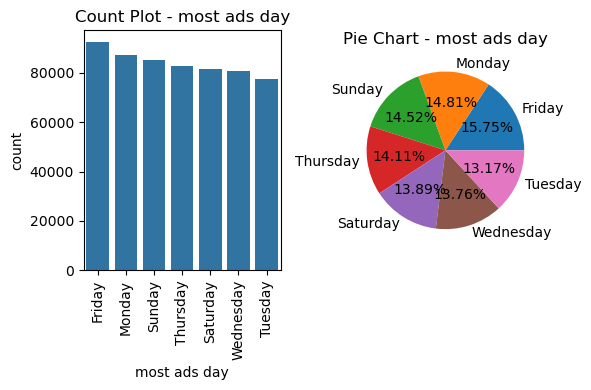

In [77]:
variable = 'most ads day'

plt.figure(figsize = (6,4))

#Count plot
plt.subplot(1,2,1)
sns.countplot(x= variable, data= df_cat, order= df_cat['most ads day'].value_counts().index)
plt.title (f'Count Plot - {variable}')
plt.xticks(rotation = 90)

import matplotlib.pyplot as plt
from importlib import reload
reload(plt)

# Pie Chart
plt.subplot(1,2,2)
counts= df_cat[variable].value_counts()
plt.pie(counts, labels= counts.index, autopct= '%0.2f%%')
plt.title(f'Pie Chart - {variable}')

#Adjust
plt.tight_layout()

# Show the chart
plt.show()

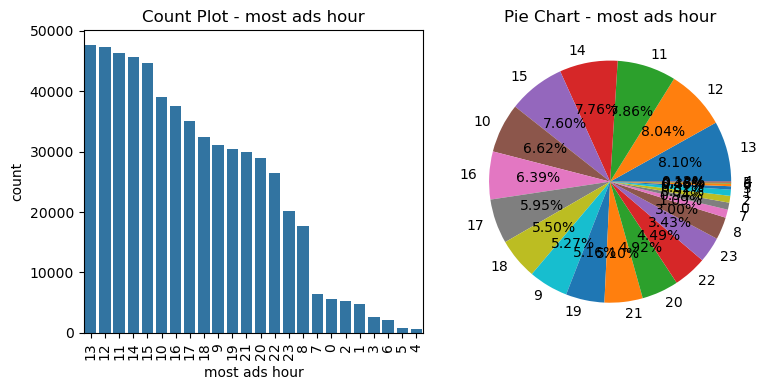

In [78]:
variable = 'most ads hour'

plt.figure(figsize = (8,4))

#Count plot
plt.subplot(1,2,1)
sns.countplot(x= variable, data= df_cat, order= df_cat['most ads hour'].value_counts().index)
plt.title (f'Count Plot - {variable}')
plt.xticks(rotation = 90)

import matplotlib.pyplot as plt
from importlib import reload
reload(plt)

# Pie Chart
plt.subplot(1,2,2)
counts= df_cat[variable].value_counts()
plt.pie(counts, labels= counts.index, autopct= '%0.2f%%')
plt.title(f'Pie Chart - {variable}')

#Adjust
plt.tight_layout()

# Show the chart
plt.show()

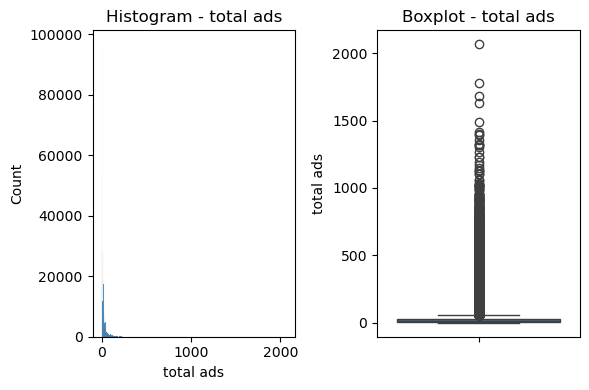

In [79]:
variable = 'total ads'

plt.figure(figsize = (6,4))

#Histogram
plt.subplot(1,2,1)
sns.histplot(x= variable, data= df)
plt.title (f'Histogram - {variable}')

import matplotlib.pyplot as plt
from importlib import reload
reload(plt)

# Box Plot
plt.subplot(1,2,2)
sns.boxplot(y= variable, data= df)
plt.title(f'Boxplot - {variable}')

#Adjust
plt.tight_layout()

# Show the chart
plt.show()


In [72]:
# Check the discriptive stats of this
df['total ads'].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64

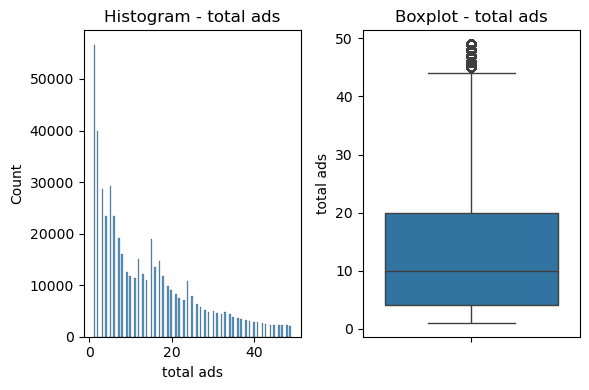

In [80]:
variable = 'total ads'

plt.figure(figsize = (6,4))

#Histogram
plt.subplot(1,2,1)
sns.histplot(x= variable, data= df [df['total ads'] < 50])
plt.title (f"Histogram - {variable}")

import matplotlib.pyplot as plt
from importlib import reload
reload(plt)

# Box Plot
plt.subplot(1,2,2)
sns.boxplot(y= variable, data= df [df['total ads'] < 50])
plt.title(f'Boxplot - {variable}')

#Adjust
plt.tight_layout()

# Show the chart
plt.show()


In [82]:
# Bivariate Analysis

In [83]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [107]:
ct_conversion_test_group = pd.crosstab(df['test group'], df['converted'], normalize = 'index')
ct_conversion_test_group


converted,False,True
test group,,
ad,0.974453,0.025547
psa,0.982146,0.017854


<Axes: xlabel='test group'>

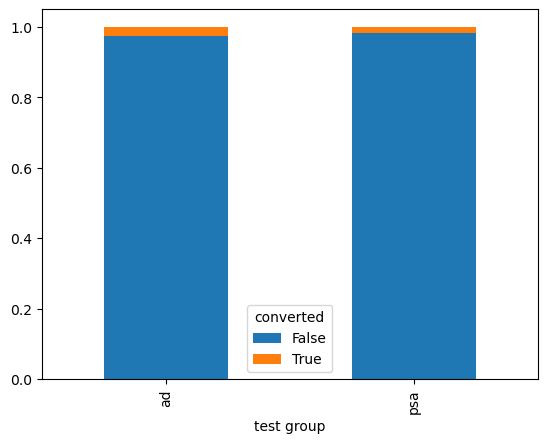

In [87]:
ct_conversion_test_group.plot.bar(stacked= True)

converted        False     True 
most ads day                    
Monday        0.967188  0.032812
Tuesday       0.970160  0.029840
Wednesday     0.975058  0.024942
Sunday        0.975524  0.024476
Friday        0.977788  0.022212
Thursday      0.978429  0.021571
Saturday      0.978949  0.021051


<Axes: xlabel='most ads day'>

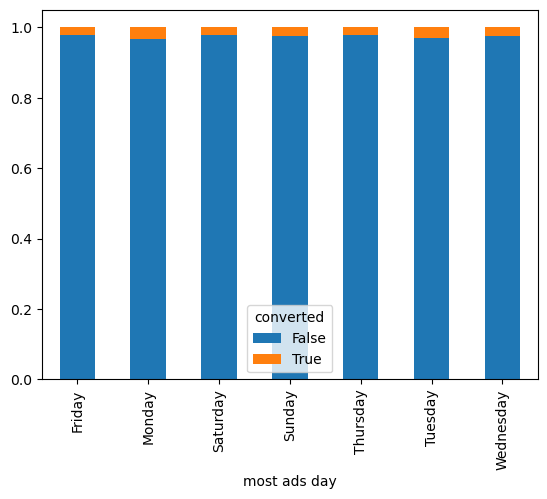

In [90]:
ct_conversion_day = pd.crosstab(df['most ads day'], df['converted'], normalize = 'index')
print(ct_conversion_day.sort_values(by = True, ascending= False))
ct_conversion_day.plot.bar(stacked= True)


converted         False     True 
most ads hour                    
16             0.969228  0.030772
20             0.970197  0.029803
15             0.970347  0.029653
21             0.971077  0.028923
17             0.971790  0.028210
14             0.971937  0.028063
18             0.972620  0.027380
19             0.973280  0.026720
22             0.973895  0.026105
13             0.975323  0.024677
12             0.976172  0.023828
23             0.977338  0.022662
6              0.977756  0.022244
11             0.977884  0.022116
10             0.978479  0.021521
5              0.979085  0.020915
8              0.980484  0.019516
9              0.980809  0.019191
0              0.981575  0.018425
7              0.981889  0.018111
4              0.984765  0.015235
1              0.987089  0.012911
3              0.989548  0.010452
2              0.992687  0.007313


<Axes: xlabel='most ads hour'>

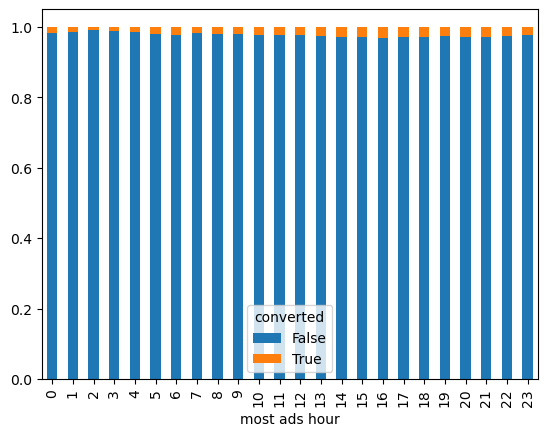

In [91]:
ct_conversion_hour = pd.crosstab(df['most ads hour'], df['converted'], normalize = 'index')
print(ct_conversion_hour.sort_values(by = True, ascending= False))
ct_conversion_hour.plot.bar(stacked= True)

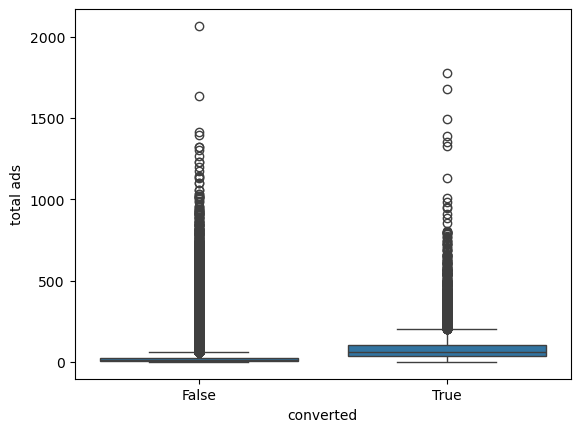

In [93]:
sns.boxplot(x= 'converted', y= 'total ads', data= df);

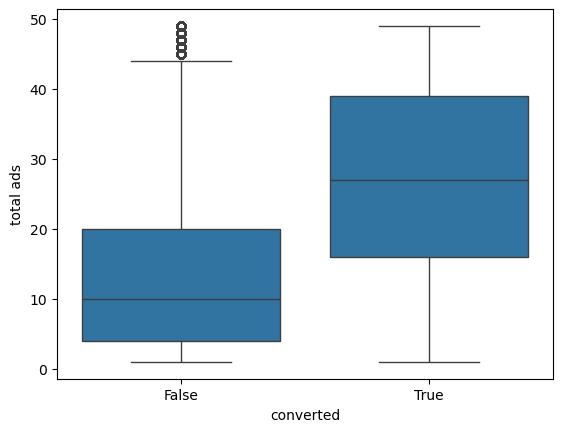

In [97]:
sns.boxplot(x= 'converted', y= 'total ads', data= df [df[ 'total ads'] < 50]);

In [109]:
from scipy.stats import chi2_contingency
alpha = 0.05
for variable in df_cat.columns:
    if variable != 'converted':
        #Creating a contingency table
        contingency_table = pd.crosstab(df_cat[variable], df_cat['converted'])

        #Perfoem Chi Square
        chi2, p, _, _= chi2_contingency(contingency_table)

        #Display Results
        print(f'\nChi Square test for {variable} vs. converted:')
        print(f'\nChi Square Value: {chi2}')
        print(f'\nP value: {p}')

        # Check for significance
        if p < alpha:
            print(f'The difference is conversion rates across {variable} is statistically significant')
        else:
            print(f'There is no significant difference in conversion rates across {variable}')








Chi Square test for test group vs. converted:

Chi Square Value: 54.005823883685245

P value: 1.9989623063390078e-13
The difference is conversion rates across test group is statistically significant

Chi Square test for most ads day vs. converted:

Chi Square Value: 410.0478857936585

P value: 1.932184379244731e-85
The difference is conversion rates across most ads day is statistically significant

Chi Square test for most ads hour vs. converted:

Chi Square Value: 430.76869230822086

P value: 8.027629823696774e-77
The difference is conversion rates across most ads hour is statistically significant


In [110]:
df_cat.columns

Index(['test group', 'converted', 'most ads day', 'most ads hour'], dtype='object')

In [125]:
from scipy.stats import shapiro, levene

# Step for Check Assumption
shapiro_stat_true, shapiro_p_value_true = shapiro(df[df['converted']== True]['total ads'])
shapiro_stat_false, shapiro_p_value_false = shapiro(df[df['converted']== False]['total ads'])

print(f'Shapiro wilk test for normality (True Group): P Value= {shapiro_p_value_true}')
print(f'Shapiro wilk test for normality (False Group): P Value= {shapiro_p_value_false}')

# Equality of variance assumption
levene_stat, levene_p_value = levene(df[df['converted']]['total ads'], df[~df['converted']]['total ads'])
print(f"Levene's test for equality of variances: P value= {levene_p_value}")


Shapiro wilk test for normality (True Group): P Value= 1.638680987007771e-98
Shapiro wilk test for normality (False Group): P Value= 9.883049430735801e-204
Levene's test for equality of variances: P value= 0.0
